Después de limpiar:
    Tienda      Mes  Ventas
0  Local A    Enero     120
1  Local A  Febrero     150
2  Local A    Marzo     170
3  Local B    Enero     200
4  Local B  Febrero     220
Tienda    object
Mes       object
Ventas     int64
dtype: object


/tmp/ipython-input-211805600.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
/tmp/ipython-input-211805600.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Tienda", y="Ventas", data=df, estimator=np.sum, palette="Blues_d")


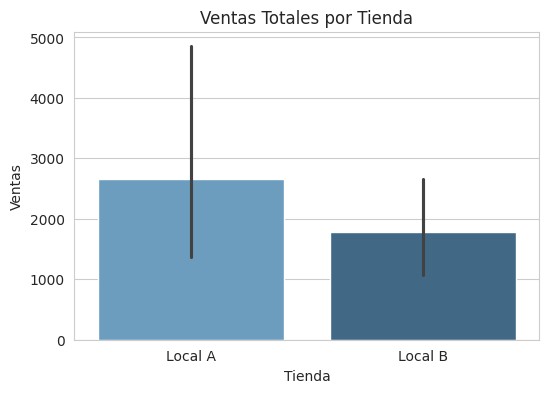

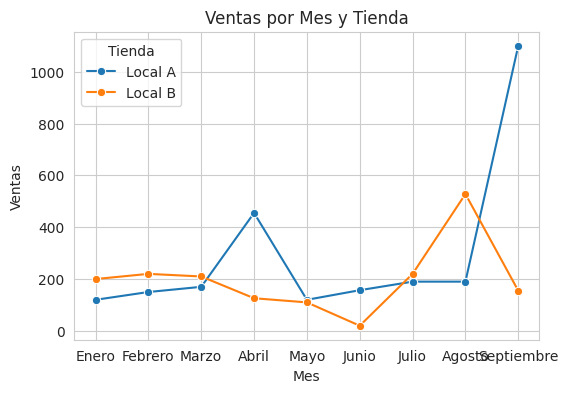

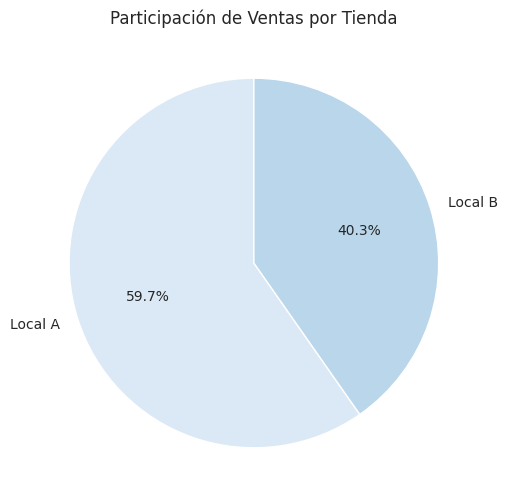

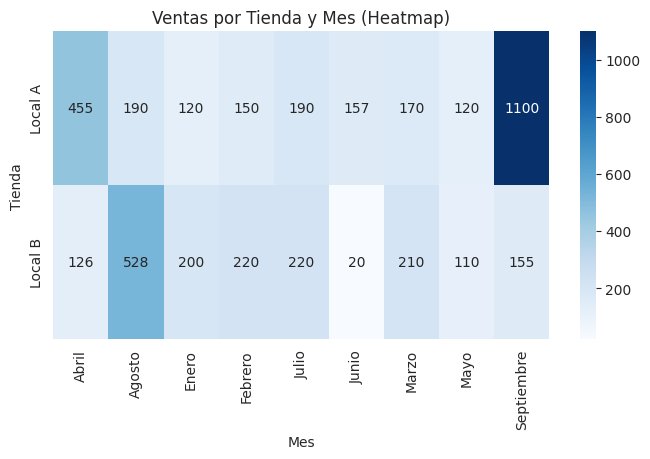

In [54]:
import pandas as pd

# Leer CSV normalmente
df = pd.read_csv("data/ventas.csv")


# Separar la única columna por coma
df = df.iloc[:, 0].str.split(',', expand=True)

# Renombrar columnas
df.columns = ['Tienda', 'Mes', 'Ventas']

# Quitar espacios
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Convertir Ventas a numérico
df['Ventas'] = pd.to_numeric(df['Ventas'], errors='coerce')

# Verificar resultado
print("Después de limpiar:")
print(df.head())
print(df.dtypes)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

sns.set_style("whitegrid")
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(6,4))
sns.barplot(x="Tienda", y="Ventas", data=df, estimator=np.sum, palette="Blues_d")
plt.title("Ventas Totales por Tienda")
plt.savefig("images/ventas_tienda.png")
plt.show()

plt.figure(figsize=(6,4))
sns.lineplot(x="Mes", y="Ventas", hue="Tienda", data=df, marker="o")
plt.title("Ventas por Mes y Tienda")
plt.savefig("images/ventas_mes.png")
plt.show()

# Ventas totales por tienda
ventas_totales = df.groupby('Tienda')['Ventas'].sum()

plt.figure(figsize=(6,6))
plt.pie(ventas_totales, labels=ventas_totales.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Blues"))
plt.title("Participación de Ventas por Tienda")
plt.savefig("images/ventas_tienda_pie.png")
plt.show()

# Pivotar datos
pivot = df.pivot(index='Tienda', columns='Mes', values='Ventas')

plt.figure(figsize=(8,4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Ventas por Tienda y Mes (Heatmap)")
plt.savefig("images/ventas_heatmap.png")
plt.show()
